In [113]:
import os
import numpy as np
import json
import torch
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models

In [139]:
def get_min_losses(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    result = {}
    for split in ["train", "val"]:
        result[split] = {}
        for loss_type in ["image", "timepoint", "weighted_loss"]:
            losses = data["losses"][split].get(loss_type, [])
            result[split][loss_type] = min(losses) if losses else None
    return result

def collect_all_losses(studies, results_base="results", only_best=False):
    all_losses = defaultdict(lambda: defaultdict(dict))

    for study in studies:
        study_path = os.path.join(results_base, study)
        if not os.path.isdir(study_path):
            continue

        experiment_dirs = sorted(os.listdir(study_path))

        for experiment in experiment_dirs:
            experiment_path = os.path.join(study_path, experiment)
            if not os.path.isdir(experiment_path):
                continue

            model_dirs = ["_best_model"] if only_best else [d for d in os.listdir(experiment_path) if d != "_best_model"]

            for model_dir in model_dirs:
                model_path = os.path.join(experiment_path, model_dir)
                dataset_path = os.path.join(model_path, os.listdir(model_path)[0])
                results_path = os.path.join(dataset_path, "results.json")
                if not os.path.isfile(results_path):
                    continue

                min_losses = get_min_losses(results_path)
                all_losses[study][experiment][model_dir] = min_losses

    return all_losses

def plot_loss_comparison(loss_data, figsize=(10, 6), save_path=None):
    records = []
    for study, experiments in loss_data.items():
        for experiment, models in experiments.items():
            for model_name, losses in models.items():
                for loss_type in ["image", "timepoint"]:
                    for split in ["train", "val"]:
                        loss_value = losses[split].get(loss_type)
                        if loss_value is not None:
                            records.append({
                                "Study": study,
                                "Experiment": experiment,
                                "Model": model_name,
                                "Split": "Train" if split == "train" else "Validation",
                                "Loss Type": "Image" if loss_type == "image" else "Timepoint",
                                "Loss": loss_value
                            })

    df = pd.DataFrame(records)

    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = plt.gca()

    experiments = df["Experiment"].unique()
    width = 0.12  # thinner bars
    x = np.arange(len(experiments)) * 0.8

    bar_order = [
        ("Train", "Image"),
        ("Validation", "Image"),
        ("Train", "Timepoint"),
        ("Validation", "Timepoint")
    ]

    gap = 0.0

    for i, exp in enumerate(experiments):
        exp_df = df[df["Experiment"] == exp]
        for j, (split, loss_type) in enumerate(bar_order):
            bar_df = exp_df[
                (exp_df["Split"] == split) &
                (exp_df["Loss Type"] == loss_type)
            ]
            if bar_df.empty:
                continue

            loss = bar_df["Loss"].values[0]
            if loss_type == "Image":
                loss *= 75

            offset_base = j
            if j >= 2:
                offset_base += gap 
            offset = (offset_base - 1.5) * width

            label = f"{split} - {loss_type}" if i == 0 else ""

            bar_kwargs = {
                "x": x[i] + offset,
                "height": loss,
                "width": width,
                "edgecolor": "black",
                "label": label,
                "linewidth": 2.0,
                "color": "none"
            }

            if loss_type == "Timepoint":
                if split == "Train":
                    bar_kwargs["hatch"] = "//"
                else:
                    bar_kwargs["hatch"] = "xxx"
            else:
                if split == "Validation":
                    bar_kwargs["color"] = "gray"

            ax.bar(**bar_kwargs)

    ax.set_xticks([])
    # ax.set_xticklabels(experiments, rotation=45, ha='right')
    ax.set_yticks([])
    sns.despine()
    ax.grid(False)
    # ax.tick_params(axis='y', labelsize=24)
    # plt.legend(frameon=False, title="Split - Type")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
    else:
        plt.show()
        
def load_accuracy_data(json_paths):
    records = []

    for path in json_paths:
        if not os.path.isfile(path):
            print(f"Warning: File not found - {path}")
            continue

        with open(path, "r") as f:
            data = json.load(f)

        study_name = data.get("study_name", os.path.basename(path))
        for result in data["model_dataset_results"]:
            model = result["model_name"]
            dataset = result["dataset_name"]
            correct = result["total_correct"]
            incorrect = result["total_incorrect"]
            total = correct + incorrect
            accuracy = correct / total if total > 0 else 0.0

            records.append({
                "Study": study_name,
                "Model": model,
                "Dataset": dataset,
                "Accuracy": accuracy
            })

    return pd.DataFrame(records)

def plot_accuracy_bars(df, figsize=(10, 6), save_path=None):
    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x="Model",
        y="Accuracy",
        hue="Split", 
        dodge=True,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=16)
    ax.set_xlabel("Model", fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=24)
    ax.grid(False)
    plt.legend('',frameon=False)
    sns.despine()
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

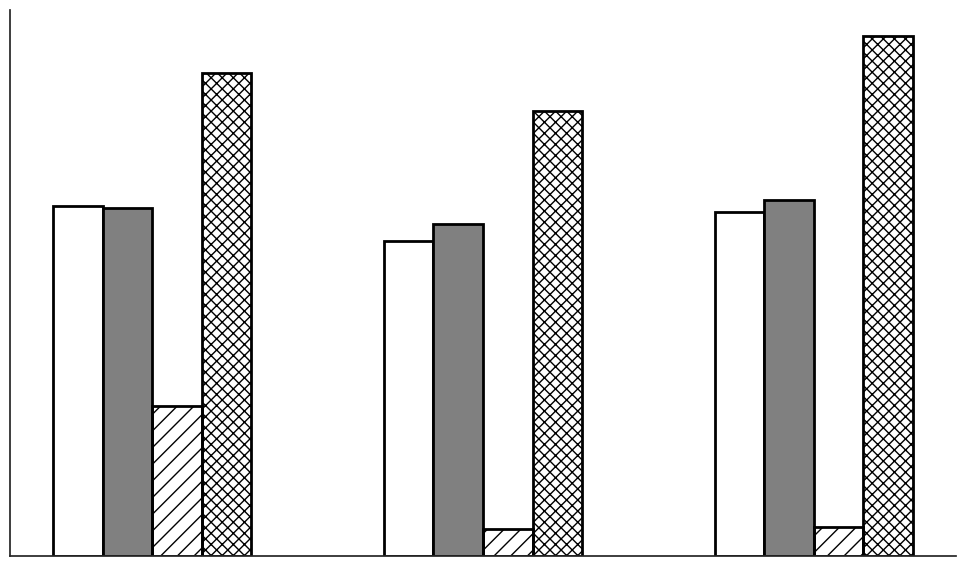

In [130]:
studies = ["ae-architecture-gastruloid", "cae-latentdim-gastruloid", "neuralop-architecture-gastruloid"]
loss_data = collect_all_losses(studies, only_best=True)

# Filter experiments
for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment and "2" not in experiment and "4" not in experiment and "large" not in experiment
    }
model_type = "gastruloid-all"
plot_loss_comparison(loss_data, save_path=f"figures/plots/{model_type}_combined_loss.png")

In [108]:
studies = [
    "ae-architecture-gastruloid",
    "cae-latentdim-gastruloid",
    "neuralop-architecture-gastruloid"
]
image_dir = "data"
num_timepoints = 9
all_models = {}
all_loaders = {}

for study_name in studies:
    results_dir = f"results/{study_name}"

    models = load_models(results_dir, num_timepoints=num_timepoints, best_models_flag=True)
    filtered_models = {
        k: v for k, v in models.items()
        if all(sub not in k for sub in ["small", "2", "4", "large"])
    }
    all_models[study_name] = dict(sorted(filtered_models.items()))

    loaders = load_loaders(results_dir, image_dir)
    all_loaders[study_name] = loaders

for study, models in all_models.items():
    print(f"{study}: {list(models.keys())}")

Loading model ae_small (3.50e+07 parameters)
Loading model ae_medium (7.27e+07 parameters)
Loading model cae_medium (8.69e+06 parameters)
Loading model cae_medium (8.72e+06 parameters)
Loading model cae_medium (8.69e+06 parameters)
Loading model cae_medium (8.70e+06 parameters)
Loading model neuralop_small (3.39e+07 parameters)
Loading model neuralop_large (6.82e+07 parameters)
Loading model neuralop_medium (3.41e+07 parameters)
Loading model neuralop_large (6.82e+07 parameters)
ae-architecture-gastruloid: ['ae-medium']
cae-latentdim-gastruloid: ['cae-16']
neuralop-architecture-gastruloid: ['neuralop-medium']


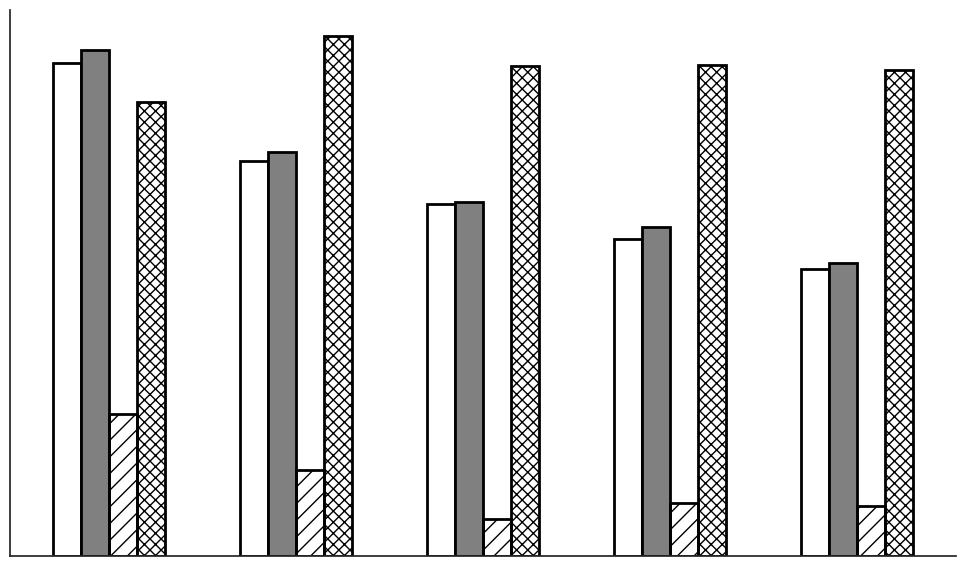

In [140]:
studies = ["neuralop-latentdim-gastruloid"]
loss_data = collect_all_losses(studies, only_best=True)
model_type = "neuralop"
plot_loss_comparison(loss_data, save_path=f"figures/plots/{model_type}_combined_loss.png")

defaultdict(<function collect_all_losses.<locals>.<lambda> at 0x1324a96c0>, {'ae-architecture-ARCADE': {'ae-medium': {'_best_model': {'train': {'image': 0.0004798223865305307, 'timepoint': 2.7770215279255623, 'weighted_loss': 0.0004798223865305307}, 'val': {'image': 0.0004883469216323686, 'timepoint': 2.742184111412535, 'weighted_loss': 0.0004883469216323686}}}}, 'cae-architecture-ARCADE': {'cae-medium': {'_best_model': {'train': {'image': 0.0006211892247086698, 'timepoint': 0.617854518243517, 'weighted_loss': 0.062344523097122115}, 'val': {'image': 0.0005893427599190506, 'timepoint': 1.1715818642777331, 'weighted_loss': 0.11772151449893384}}}}, 'neuralop-latentdim-ARCADE-16': {'neuralop-16': {'_best_model': {'train': {'image': 0.0007607217664709629, 'timepoint': 0.8457105048066981, 'weighted_loss': 0.08607112790323913}, 'val': {'image': 0.0007513467790750896, 'timepoint': 1.2701664387862732, 'weighted_loss': 0.1277193862231488}}}}})


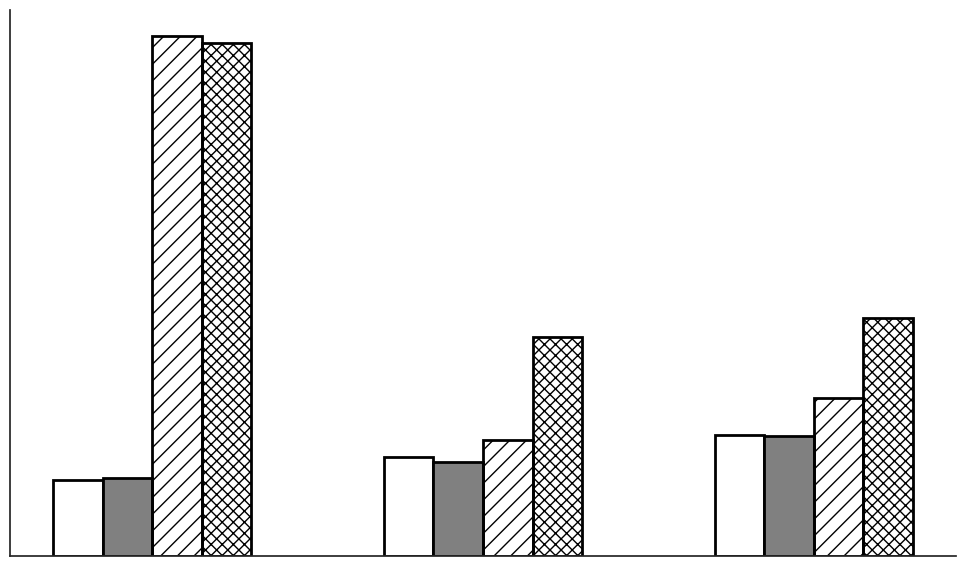

In [137]:
studies = ["ae-architecture-ARCADE", "cae-architecture-ARCADE", "neuralop-latentdim-ARCADE-16"]
loss_data = collect_all_losses(studies, only_best=True)

for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment
    }

print(loss_data)
model_type = "ARCADE-all"
plot_loss_comparison(loss_data, save_path=f"figures/plots/{model_type}_combined_loss.png")

In [68]:
json_files = [
    "results_downstream/ae-architecture-gastruloid_classification_results.json",
    "results_downstream/cae-architecture-gastruloid_classification_results.json",
    "results_downstream/neuralop-latentdim-gastruloid-16_classification_results.json"
]

df = load_accuracy_data(json_files)
df_filtered = df[~df["Model"].str.contains("medium", case=False)]



df = pd.DataFrame([
    {"Model": "model-a", "Split": "Train", "Accuracy": 0.70},
    {"Model": "model-a", "Split": "Test",  "Accuracy": 0.67},
    {"Model": "model-b", "Split": "Train", "Accuracy": 0.76},
    {"Model": "model-b", "Split": "Test",  "Accuracy": 0.70},
    {"Model": "model-c", "Split": "Train", "Accuracy": 0.84},
    {"Model": "model-c", "Split": "Test",  "Accuracy": 0.76},
])


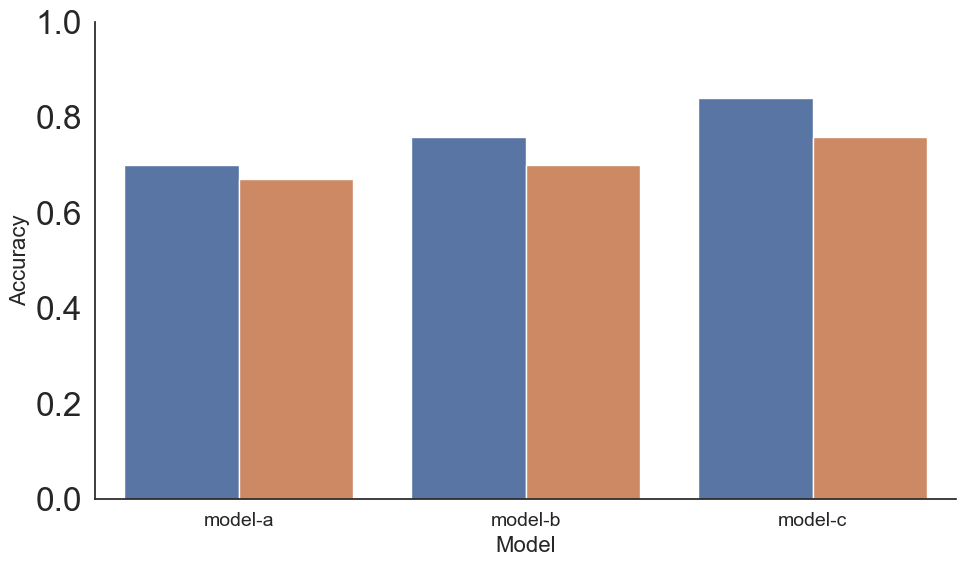

In [69]:
plot_accuracy_bars(df)